# Проект. Исследование стартапов

Автор: Ульзана Давлетова

## Цели и задачи проекта

**Целью** проекта является исследование динамики и структуры финансирования стартапов.<br>
Основные **задачи** исследования:
 - куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год;
 - какие типы финансирования в сумме привлекли больше всего денег;
 - какие типы финансирования чаще всего используются компаниями;
 - насколько активно происходили инвестиции на рынке;
 - как менялся суммарный размер общего финансирования;
 - какова доля возвращённых средств по типам финансирования.

### Содержание проекта

1. Загрузка данных и знакомство с ними. Предобработка данных
2. Инжиниринг признаков
3. Работа с выбросами
4. Анализ
5. Итоговый вывод и рекомендации

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.


In [1]:
# Импортируем необходимые библиотеки

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Добавим функции, которые понадобятся для анализа

# Функция для вывода общих данных по датасету
def data_info(data):
    print('Информация о датасете:')
    print (data.info())
    print ('________________________________________________')
    print ('Первые 5 строк датасета:')
    if len(data.columns) <=15:
        display (data.head())
    else:
        display(data.head().T)
    print ('________________________________________________')
    print ('Количество пропусков в абсолютном выражении:')
    print (data.isna().sum().sort_values())
    print ('________________________________________________')
    print ('Количество пропусков в относительном выражении:')
    print (data.isna().mean().sort_values().round(3))
    print ('________________________________________________')
    duplicates = data.duplicated().sum()
    print('Наличие дубликатов в абсолютном выражении:')
    print (duplicates)
    print('Наличие дубликатов в относительном выражении:')
    print ((duplicates/data.shape[0]).round(2))

# Отбражение всех колонок pd.set_option('display.max_columns', None)
# Функция для отображения уникальных значений
def unique_values_data (data, columns):
    for column in columns:
        print(f'Уникальные значения в столбце "{column}":')
        print(data[column].sort_values().unique())
        print()

# Числовые значения для диаграмм barh или bar
def extra_for_diagr(kind='bar'):
    if kind=='barh':
        for bar in diagr.patches:
            width = bar.get_width()
            plt.text(
                width,  # координата x
                bar.get_y() + bar.get_height()/2,  # координата y
                f'{width}',
                ha='left', 
                va='center',
                fontsize=12,
                color='black')
    else:
        for bar in diagr.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1,  # смещение сверху
                f'{height}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black')
    plt.grid(0.4)
    plt.tight_layout()
    plt.show()

In [3]:
# Выгружаем данные
investments = pd.read_csv('https://code.s3.yandex.net/datasets/cb_investments.zip', sep=';', low_memory=False)
returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [4]:
# Познакомимся с данными основного датасета
data_info (investments)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 

,0,1,2,3,4
name,Harvard University,University of New Brunswick,DuPont,University of Michigan,Case Western Reserve University
homepage_url,http://harvard.edu,http://www.unb.ca,http://www.dupont.com,http://www.umich.edu/,http://www.case.edu
category_list,|Education|,NaN,|Business Services|Agriculture|Automotive|Inve...,|Education|,|Education|
market,Education,NaN,Business Services,Education,Education
funding_total_usd,"9,00,00,000","20,00,000","90,00,000","77,00,000","5,40,000"
status,operating,operating,operating,operating,operating
country_code,USA,NaN,USA,USA,USA
state_code,MA,NaN,DE,MI,OH
region,Boston,NaN,"Wilmington, Delaware",Detroit,Cleveland
city,Cambridge,NaN,Wilmington,Ann Arbor,Cleveland


________________________________________________
Количество пропусков в абсолютном выражении:
seed                     4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
equity_crowdfunding      4856
post_ipo_debt            4856
product_crowdfunding     4856
round_A                  4856
round_B                  4856
round_C                  4856
round_D                  4856
round_E                  4856
round_F                  4856
secondary_market         4856
venture                  4856
round_H                  4856
last_funding_at          4856
 funding_total_usd       4856
first_funding_at         4856
round_G                  4856
funding_rounds           4856
name                     4857
status                   6170
homepage_url             8305
 market                  8817
category_list            8817
region

<div style="background-color: #f9f0ff">

Датасет содержит 54294 строк и 40 столбцов.<br>
Названия столбцов имеют стандартный вид snake_case. Подозрения, что есть лишние пробелы в заголовках.<br>
Типы данных в некоторых столбцах можно поменять на более подходящий:
 - `funding_total_usd` -  с object на int
 - `funding_rounds` и `participants` - с float на int
 - `first_funding_at`, `mid_funding_at`, `last_funding_at` - c object на datetime<br>

<div style="background-color: #f9f0ff">

Если числовые значения имеют много нулей, можно их сократить до млн дол.<br>
Все столбцы имеют пропуски. Так как проводится анализ инвестиционных показателей, то строки, не имеющие основных финансовых данных можно удалить.<br>
Есть пропуски в столбце `name`. Нужно рассмотреть возможность удаления строк с этими пропусками.<br>
Количество дубликатов - 4855, что составляет 9% от всех данных. В процессе обработки от них нужно избавиться.

In [5]:
# Посмотрим уникальные значения в столбцах и проверим на наличие ошибок и повторений в различных регистрах
unique_values_data (investments, columns=['status', 'country_code','state_code', 'region', 'city'])

Уникальные значения в столбце "status":
['acquired' 'closed' 'operating' nan]

Уникальные значения в столбце "country_code":
['ALB' 'ARE' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BEL' 'BGD' 'BGR' 'BHR' 'BHS'
 'BLR' 'BMU' 'BRA' 'BRN' 'BWA' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COL'
 'CRI' 'CYM' 'CYP' 'CZE' 'DEU' 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ESP' 'EST'
 'FIN' 'FRA' 'GBR' 'GHA' 'GIB' 'GRC' 'GTM' 'HKG' 'HRV' 'HUN' 'IDN' 'IND'
 'IRL' 'ISL' 'ISR' 'ITA' 'JAM' 'JEY' 'JOR' 'JPN' 'KEN' 'KHM' 'KOR' 'KWT'
 'LAO' 'LBN' 'LIE' 'LTU' 'LUX' 'LVA' 'MAF' 'MAR' 'MCO' 'MDA' 'MEX' 'MKD'
 'MLT' 'MMR' 'MOZ' 'MUS' 'MYS' 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN'
 'PAK' 'PAN' 'PER' 'PHL' 'POL' 'PRT' 'ROM' 'RUS' 'SAU' 'SGP' 'SLV' 'SOM'
 'SRB' 'SVK' 'SVN' 'SWE' 'SYC' 'THA' 'TTO' 'TUN' 'TUR' 'TWN' 'TZA' 'UGA'
 'UKR' 'URY' 'USA' 'UZB' 'VNM' 'ZAF' 'ZWE' nan]

Уникальные значения в столбце "state_code":
['AB' 'AK' 'AL' 'AR' 'AZ' 'BC' 'CA' 'CO' 'CT' 'DC' 'DE' 'FL' 'GA' 'HI'
 'IA' 'ID' 'IL' 'IN' 'KS' 'KY' 'LA' 'MA' 'MB' 'MD' 'ME

<div style="background-color: #f9f0ff">
    
Только столбец `market` невозможно отобразить. Анализ этого столбца будет далее.<br>Другие столбцы имеют корректные значения, улучшения не требуются.

---
<div style="background-color: #f9f0ff">
    
Рассмотрим следующий датасет `returns`, используя для этого функцию:

In [6]:
data_info (returns)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB
None
__

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


________________________________________________
Количество пропусков в абсолютном выражении:
year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
year                    0.0
seed                    0.0
venture                 0.0
equity_crowdfunding     0.0
undisclosed             0.0
convertible_note        0.0
debt_financing          0.0
angel                   0.0
grant                   0.0
private_equity          0.0
post_ipo_equity         0.0
post_ipo_debt           0.0
secondary_market        0.0
product_crowdfunding    0.0
dtype: float64
_________________________

<div style="background-color: #f9f0ff">Дополнительный датасет имеет 15 строк и 14 столбцов. <br>Названия столбцов имеют стандартный вид snake_case.<br>
Пропусков и дубликатов нет. Никаких преобразований не требуется.

### 1.2. Предобработка данных

In [7]:
# Удаляем пробелы в названиях столбцов
investments.columns = investments.columns.str.strip()

<div style="background-color: #f9f0ff">
    
Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [8]:
# Убираем выделение разрядов
investments['funding_total_usd']=investments['funding_total_usd'].str.replace(',', '')
# При попытке изменить тип данных возникла ошибка: в данных были прочерки. Заменим их на пропуски
investments['funding_total_usd'] = investments['funding_total_usd'].str.strip()
investments['funding_total_usd'] = investments['funding_total_usd'].replace('-', 'NaN')
investments['funding_total_usd'] = investments['funding_total_usd'].astype(float)

In [9]:
# Избавимся от больших чисел, поделив на 1 000 000. Единицей измерения станет млн дол.
investments[[
    'funding_total_usd', 'seed', 'venture', 'equity_crowdfunding',  'undisclosed', 'convertible_note', 'debt_financing', 
    'angel',  'grant',  'private_equity', 'post_ipo_equity', 'post_ipo_debt',  'secondary_market', 'product_crowdfunding'
]] = investments [[
    'funding_total_usd', 'seed', 'venture', 'equity_crowdfunding',  'undisclosed',  'convertible_note', 'debt_financing',
    'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt',  'secondary_market', 'product_crowdfunding'
]]/1000000

investments[[
    'funding_total_usd', 'seed', 'venture', 'equity_crowdfunding',  'undisclosed', 'convertible_note',  'debt_financing',
    'angel', 'grant', 'private_equity',  'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]] = investments [[
    'funding_total_usd', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing',
    'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]].replace({0: np.nan})

<div style="background-color: #f9f0ff">
    
Обработаем типы данных в столбцах `first_funding_at`, `mid_funding_at`, `last_funding_at`, которые хранят значения даты и времени.

In [10]:
for column in ['first_funding_at', 'mid_funding_at', 'last_funding_at']:
    investments[column] = pd.to_datetime(investments[column], errors='coerce')

<div style="background-color: #f9f0ff">
    
Столбцы `funding_rounds`, `participants`, `founded_year` приведем к оптимальному типу данных:

In [11]:
for column in ['funding_rounds', 'participants', 'founded_year']:
    investments[column] = investments[column].fillna('0')
    investments[column] = pd.to_numeric(investments[column], errors='coerce', downcast='integer') 

<div style="background-color: #f9f0ff">
    
Проверим столбец `market` на наличие ошибок в данных.<br>При первичном выводе значений столбца выяснилось, что в каждой строке есть дополнительные ненужные пробелы. Откорректируем данные.

In [12]:
investments['market'] = investments['market'].str.strip().str.lower()

<div style="background-color: #f9f0ff">
    
Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не содержат данных о финансировании.

In [13]:
# Удаляем явные дубликаты
df = investments.drop_duplicates()
# Удаляем данные без информации о финансировании
df = df[df['funding_total_usd'].notna()]

In [14]:
# Посмотрим пропуски в названии компании
df[df['name'].isna()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
27212,NaN,http://tellitin10.com,|Startups|,startups,0.025,closed,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# Проверим, возможно, это дубликат без названия
df[df['homepage_url']=='http://tellitin10.com']

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
27212,NaN,http://tellitin10.com,|Startups|,startups,0.025,closed,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<div style="background-color: #f9f0ff">В датасете есть только одна компания с сайтом http://tellitin10.com	, поэтому посчитаем ее уникальной, необходимые финансовые показатели имеются, поэтому эта строка будет полезна в исследовании.

<div style="background-color: #f9f0ff">
    
Заполняем пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков берем приблизительно середину интервала между этими двумя датами.

In [16]:
def middle_date(row):
    if pd.isna(row['mid_funding_at']):
        return (row['last_funding_at'] - row['first_funding_at']) / 2+ row['first_funding_at']
    return row['mid_funding_at']

df['mid_funding_at'] = df.apply(middle_date, axis=1)

In [17]:
# Проверим, остались ли пропуски в этих столбцах
df[df[['mid_funding_at', 'last_funding_at', 'first_funding_at']].isna().any(axis=1)].T

,2177,33041
name,SecureNet Payment Systems,Nubank
homepage_url,http://www.securenet.com,https://www.nubank.com.br/
category_list,|Trading|Mobile Payments|Payments|E-Commerce|,|Consumer Internet|Financial Services|
market,payments,financial services
funding_total_usd,18.0,16.3
status,acquired,operating
country_code,USA,BRA
state_code,TX,NaN
region,Austin,Sao Paulo
city,Austin,São Paulo


In [18]:
# Заменим их на значения, которые уже есть в других столбцах
df.loc[[2177, 33041], ['first_funding_at', 'mid_funding_at']] = df.loc[[2177, 33041], 'last_funding_at'].values
df[df[['mid_funding_at', 'last_funding_at', 'first_funding_at']].isna().any(axis=1)]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H


In [19]:
# Удалим столбцы, которые не будут использоваться в анализе
df = df.drop(columns=[
    'category_list', 'status', 'participants', 'country_code', 'state_code', 'region', 'city', 'founded_at', 'founded_month', 'founded_quarter', 
    'founded_year', 'round_A', 'round_B','round_C','round_D','round_E','round_F','round_G','round_H'
])

<div style="background-color: #f9f0ff">
    
В датасете returns сделаем столбец `year` индексом всего датасета.

In [20]:
returns = returns.set_index('year')

<div style="background-color: #f9f0ff">Выведем датасет, который получился после предобработки

In [21]:
data_info(df)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
Index: 40907 entries, 0 to 49437
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   market                38404 non-null  object        
 3   funding_total_usd     40907 non-null  float64       
 4   funding_rounds        40907 non-null  int8          
 5   first_funding_at      40907 non-null  datetime64[ns]
 6   mid_funding_at        40907 non-null  datetime64[ns]
 7   last_funding_at       40907 non-null  datetime64[ns]
 8   seed                  13840 non-null  float64       
 9   venture               23277 non-null  float64       
 10  equity_crowdfunding   522 non-null    float64       
 11  undisclosed           952 non-null    float64       
 12  convertible_note      557 non-null    float64       
 13

,0,1,2,3,4
name,Harvard University,University of New Brunswick,DuPont,University of Michigan,Case Western Reserve University
homepage_url,http://harvard.edu,http://www.unb.ca,http://www.dupont.com,http://www.umich.edu/,http://www.case.edu
market,education,NaN,business services,education,education
funding_total_usd,90.0,2.0,9.0,7.7,0.54
funding_rounds,1,1,1,3,1
first_funding_at,2014-01-06 00:00:00,2014-05-15 00:00:00,2009-07-02 00:00:00,2013-11-21 00:00:00,2014-01-14 00:00:00
mid_funding_at,2014-01-06 00:00:00,2014-05-15 00:00:00,2009-07-02 00:00:00,2013-11-21 00:00:00,2014-01-14 00:00:00
last_funding_at,2014-01-06 00:00:00,2014-05-15 00:00:00,2009-07-02 00:00:00,2014-11-03 00:00:00,2014-01-14 00:00:00
seed,NaN,NaN,NaN,NaN,NaN
venture,NaN,2.0,9.0,NaN,NaN


________________________________________________
Количество пропусков в абсолютном выражении:
funding_total_usd           0
funding_rounds              0
first_funding_at            0
mid_funding_at              0
last_funding_at             0
name                        1
homepage_url             2314
market                   2503
venture                 17630
seed                    27067
debt_financing          36682
angel                   37778
private_equity          39534
grant                   39765
undisclosed             39955
convertible_note        40350
equity_crowdfunding     40385
post_ipo_equity         40591
product_crowdfunding    40694
post_ipo_debt           40832
secondary_market        40888
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
funding_total_usd       0.000
funding_rounds          0.000
first_funding_at        0.000
mid_funding_at          0.000
last_funding_at         0.000
name            

In [22]:
print (f'Количество строк и столбцов до предобработки: {investments.shape}')
print (f'Количество строк и столбцов после предобработки: {df.shape}')
print ('Удалено строк:')
print (f' - в количестве: {investments.shape[0]-df.shape[0]}')
print (f' - доля: {round(((investments.shape[0]-df.shape[0])/investments.shape[0]),2)}')
print ('Удалено столбцов:')
print (f' - в количестве: {investments.shape[1]-df.shape[1]}')
print (f' - доля: {round(((investments.shape[1]-df.shape[1])/investments.shape[1]),2)}')

Количество строк и столбцов до предобработки: (54294, 40)
Количество строк и столбцов после предобработки: (40907, 21)
Удалено строк:
 - в количестве: 13387
 - доля: 0.25
Удалено столбцов:
 - в количестве: 19
 - доля: 0.47


---

<div style="background-color: #f9f0ff">

**ПРОМЕЖУТОЧНЫЙ ИТОГ**

В результате предобработки данных в **основном датасете** осталось 40907 уникальных строк и 21 столбец.
 - были удалены лишние пробелы в заголовках столбцов и в значениях столбца `market`
 - откорректированы значения в столбце `funding_total_usd`
 - в столбцах, имеющих большие числовые данные, отбросили нули и привели к измерению в млн дол
 - были изменены типы данных в столбцах `mid_funding_at`, `first_funding_at` и `last_funding_at` на datetime
 - пропуски в значениях `mid_funding_at` заполнили на основании значений в столбцах `first_funding_at` и `last_funding_at`, вычислив середину интервала между этими двумя датами
 - удалили данные без информации о финансировании и полные дубликаты
 - удалили столбцы, которые не понадобятся в анализе в количестве 19.<br>

<div style="background-color: #f9f0ff">
    
Таким образом, было отброшено 25% строк. Все необходимые числовые и временные данные имеются в полном объеме. Единственный столбец `market` имеет неполные данные. Его можно было бы заполнить на основании информации в столбце `category_list`, но и он тоже имеет пропуски в тех же компаниях в том же количестве.<br>
**Дополнительный датасет** `returns` не претерпел кардинальных изменений: все столбцы и строки остались в том же количестве, типы данных не изменяли. Столбец `year` сделаи индексом всего датасета.<br>Данные готовы для анализа.

---

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

In [23]:
# Разделим компании на группы

funding_groups = []

for index, row in df.iterrows():
    if row['funding_rounds'] == 1:
        funding_groups.append('one_off_funding')
    elif ((row['last_funding_at'] - row['first_funding_at']) <= pd.Timedelta(days=365)):
        funding_groups.append('funding_less_year')
    else:
        funding_groups.append('funding_more_year')

df['funding_groups'] = funding_groups

# funding_groups - Группы по срокам финансирования:
# one_off_funding - Единичное финансирование
# funding_less_year - Срок финансирования до года
# funding_more_year - Срок финансирования более года

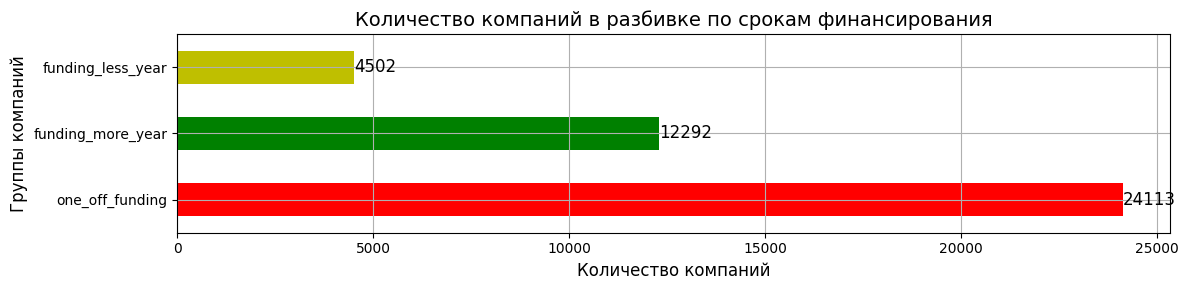

In [24]:
# Определим цвет для каждой группы
colors = {
    'one_off_funding': 'r',
    'funding_less_year': 'y',
    'funding_more_year': 'g'
}

# Рассчитаем количестко компаний в каждой группе и построим диаграмму
sorted_groups = df ['funding_groups'].value_counts().sort_values(ascending=False)

diagr = sorted_groups.plot(
        kind='barh', 
        figsize=(12,3),
        color=[colors.get(group, 'gray') for group in sorted_groups.index],
        rot=0)
plt.title('Количество компаний в разбивке по срокам финансирования', fontsize=14)
plt.xlabel('Количество компаний', fontsize=12)
plt.ylabel('Группы компаний', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
extra_for_diagr('barh')

In [25]:
# Рассчитаем объем инвестиций в каждой группе
funding_groups_invest = df.groupby('funding_groups')['funding_total_usd'].sum().reset_index()
funding_groups_invest=funding_groups_invest.set_index('funding_groups')

In [26]:
# Вычисляем доли в процентах
total_investment = funding_groups_invest['funding_total_usd'].sum()
funding_groups_invest_percent = ((funding_groups_invest['funding_total_usd'] / total_investment) * 100).round(2)
funding_groups_invest_percent = funding_groups_invest_percent.sort_values(ascending=False)

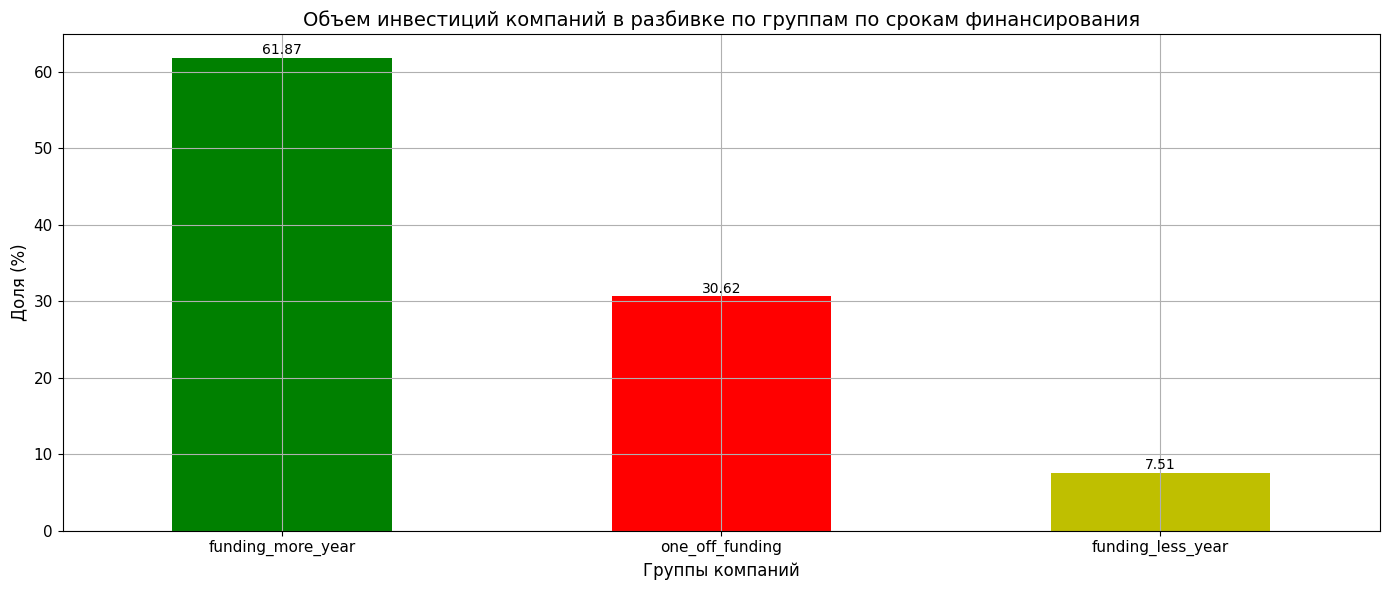

In [27]:
diagr = funding_groups_invest_percent.plot(
    kind='bar',
    figsize=(14, 6),
    color=[colors.get(group, 'gray') for group in funding_groups_invest_percent.index],
    rot=0
)
plt.title('Объем инвестиций компаний в разбивке по группам по срокам финансирования',fontsize=14)
plt.ylabel('Доля (%)', fontsize=12)
plt.xlabel('Группы компаний', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
extra_for_diagr()

<div style="background-color: #f9f0ff">В результате разбивки компаний по срокам финансирования мы видим, что большинство компаний имеет один раунд финансирования. Это наиболее предпочтительный способ быстрого "сбора денег" за один раз. Но при выборе такой стратегии компания может не привлечь планируемую сумму, это не всегда надежный вариант для привлечения инвестиций. Также подготовка к одному большому раунду может занять больше времени, чем разбивка на несколько раундов.<br>
Вторая диаграмма отражает доли инвестиций от всего объема привлеченных средств. И видим противоположную картину: больший объем инвестиций принадлежит компаниям, которые занимаются более продолжительным по срокам привлечением среств.  Самый непопулярная стратегия - проведение нескольких раундов с пределах одного года.

### 2.2 Выделение средних и нишевых сегментов рынка

Рассчитаем, как часто в датасете встречается каждый из сегментов рынка. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний  -  к нишевым.

In [28]:
import pandas as pd

# Создаём таблицу частот
df_markets = df['market'].value_counts().sort_values().reset_index()

df_markets.columns = ['market', 'frequency']  # Явно задаём имена столбцов

# Разбиваем частоты на сегменты
bins = [0, 35, 120, float('inf')]
labels = ['niche', 'mid', 'mass']
df_markets['segments'] = pd.cut(
    df_markets['frequency'],
    bins=bins,
    labels=labels,
    right=False  # Левая граница включена, правая — нет
)

print(df_markets)

               market  frequency segments
0                gold          1    niche
1              comics          1    niche
2       it management          1    niche
3                 tea          1    niche
4    natural gas uses          1    niche
..                ...        ...      ...
389       curated web       1693     mass
390        e-commerce       1866     mass
391            mobile       2344     mass
392     biotechnology       3590     mass
393          software       4812     mass

[394 rows x 3 columns]


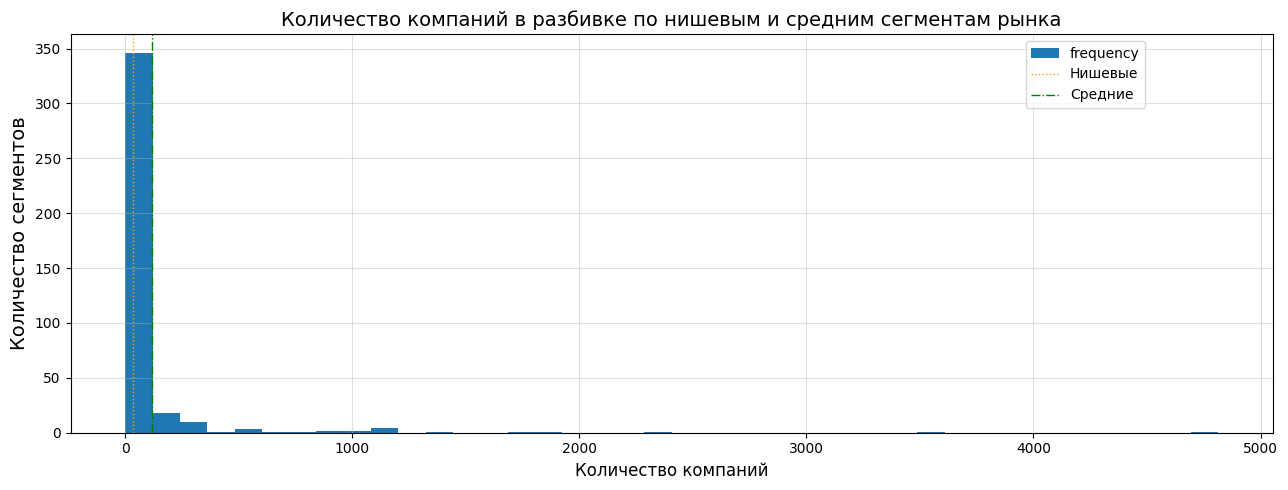

In [29]:
diagr = df_markets.plot(
    kind='hist', 
    figsize=(13, 5),
    bins=40
)

plt.title('Количество компаний в разбивке по нишевым и средним сегментам рынка', fontsize=14)
plt.xlabel('Количество компаний', fontsize=12)
plt.ylabel('Количество сегментов', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.axvline(35, color='orange', linestyle=':', linewidth=1, label='Нишевые')
plt.axvline(120, color='green', linestyle='-.', linewidth=1, label='Средние')
plt.legend(loc='upper right', bbox_to_anchor=(0.9, 1),fontsize=10)

plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

<div style="background-color: #f9f0ff">На диаграмме выше мы видим, что большинство сегментов рынка не пользуются популярностью. Причиной этому является объем финансовой отдачи вложенных средств. Как показывают расчеты, инвестиционной привлекательностью пользуются биотехнологии и ПО. <br><br>

---

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [30]:
# Заменим значения на заглушки

market_counts = df['market'].dropna().value_counts()

def segments(row):
    value = row['market']
    count = market_counts.get(value, 0) # Использовала этот метод, так как значение 'education' не обрабатывалось
    
    if 35 <= count <= 120:
        return 'mid'
    elif count < 35:
        return 'niche'
    else:
        return value

df['market'] = df.apply(segments, axis=1)

# Средние ('mid') - до 120 компаний включительно
# Нишевые ('niche') - до 35 компаний включительно

<div style="background-color: #f9f0ff">
    
**ПРОМЕЖУТОЧНЫЙ ИТОГ**

В результате разделения компаний по срокам финансирования было выявлено, что самой распространенной моделью инвестирования является долгосрочное с разбивкой на несколько раундов на длительный период времени. Несмотря на то, что большинство компаний имеют 1-раундовое финансирование, основная масса средств вращается именно в долгосрочном сегменте. В целом эта стратегия более выгодна для компании, так как привлекается большее количество инвесторов и, соответственно, вложений.<br>
В свою очередь инвестору необходимо выбрать наиболее привлекательную нишу для инвестирования, чтобы минимизировать риски. Как показало исследование, далеко не все сегменты рынка удостаиваются внимания. Далее будет более детальный анализ причин этого. 
<br>

---

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

<div style="background-color: #f9f0ff">Для этого понадобится ящик с усами, чтобы визуализировать выбросы.

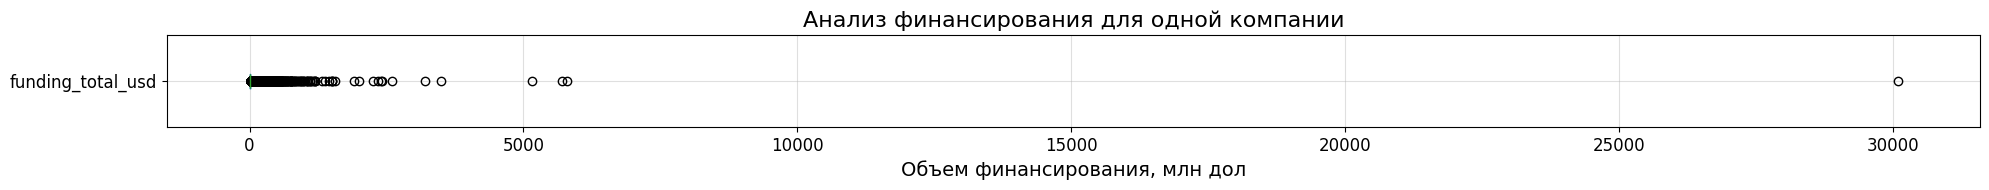

In [31]:
plt.figure(figsize=(20, 2))
df.boxplot(column='funding_total_usd', vert=False)
plt.title('Анализ финансирования для одной компании', fontsize=16)
plt.xlabel('Объем финансирования, млн дол', fontsize=14)
plt.grid(alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
# Выведем основные статистические показатели для funding_total_usd
df['funding_total_usd'].describe().reset_index().round(6)

,index,funding_total_usd
0,count,40907.000000
1,mean,15.912526
2,std,168.678800
3,min,0.000001
4,25%,0.350000
5,50%,2.000000
6,75%,10.000000
7,max,30079.503000


<div style="background-color: #f9f0ff">Мы видим значительный разброс данных и выбросы. Среднее значение, медиана и стандартное отклонение имеют большую разницу, что говорит о неоднородности данных. Интервал: от 1 дол до 5 млн дол. Попробуем отсечь выбросы

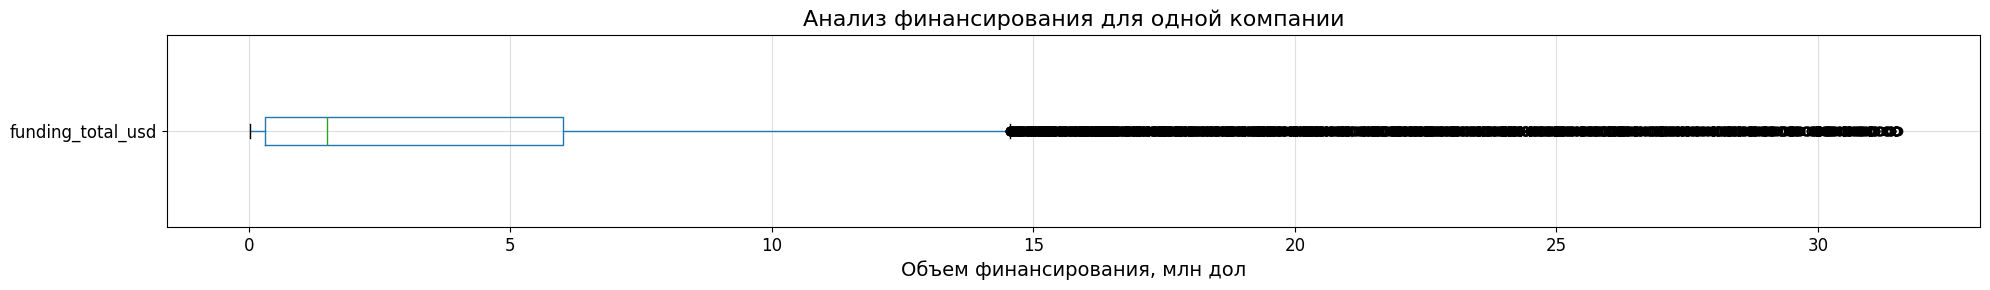

In [33]:
share_max = df['funding_total_usd'].quantile(0.90)
share_min = df['funding_total_usd'].quantile(0.01)
df_1 = df.loc[df['funding_total_usd']<=share_max]
df_value = df_1.loc[df['funding_total_usd']>=share_min]

plt.figure(figsize=(20, 3))
df_value.boxplot(column='funding_total_usd', vert=False)
plt.title('Анализ финансирования для одной компании', fontsize=16)
plt.xlabel('Объем финансирования, млн дол', fontsize=14)
plt.grid(alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
df_value['funding_total_usd'].describe().reset_index().round(3)

,index,funding_total_usd
0,count,36437.000
1,mean,4.614
2,std,6.743
3,min,0.010
4,25%,0.300
5,50%,1.500
6,75%,6.000
7,max,31.527


<div style="background-color: #f9f0ff">С удалением выбросов данные стали более равномерными. Интервал: от 10 тыс дол до 6 млн дол. Посмотрим на моду

In [35]:
mode = df['funding_total_usd'].mode().reset_index()
print (f'Типичный размер общего финансирования, млн дол: {mode.iloc[0,1]}') 

Типичный размер общего финансирования, млн дол: 1.0


Определим компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту. 
Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [36]:
df_values_segments = df.groupby('market')['funding_total_usd'].agg(
    count='count',
    mean='mean',
    std='std',
    min='min',
    median='median',
    quantile_25=lambda x: x.quantile(0.25),
    quantile_75=lambda x: x.quantile(0.75),
    max='max'
).round(2)
df_values_segments = df_values_segments.sort_values(by='max', ascending=False)

df_values_segments.head(10)

,count,mean,std,min,median,quantile_25,quantile_75,max
market,,,,,,,,
mobile,2344,23.75,622.03,0.0,1.70,0.30,7.69,30079.50
finance,828,24.63,207.58,0.0,3.12,0.50,13.45,5800.00
internet,241,39.88,374.17,0.0,1.11,0.25,5.00,5700.00
niche,3333,12.07,118.19,0.0,0.50,0.08,3.00,5162.51
mid,3841,16.07,97.29,0.0,1.50,0.25,7.85,3500.00
health and wellness,873,14.97,97.52,0.0,1.75,0.32,7.75,2600.00
social media,1003,7.91,79.69,0.0,0.67,0.12,3.00,2425.70
biotechnology,3590,21.12,56.53,0.0,5.51,1.50,22.03,2400.00
enterprise software,1381,16.69,70.38,0.0,4.50,1.00,15.00,2000.00


<div style="background-color: #f9f0ff">
    
Исходя из расчетов, максимальные выбросы имеют компании из сегментов `mobile`, `finance`, `internet`. Посмотрим в глаза самым жирным игрокам

In [37]:
df[df['funding_total_usd']>=5700]

,name,homepage_url,market,funding_total_usd,funding_rounds,first_funding_at,mid_funding_at,last_funding_at,seed,venture,...,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,funding_groups
623,Verizon Communications,http://www.verizon.com/?lid=//global//residential,mobile,30079.503,5,2010-01-26,2012-02-12,2014-02-28,NaN,NaN,...,NaN,30079.503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,funding_more_year
7074,Clearwire,http://www.clearwire.com,internet,5700.000,4,2008-05-06,2009-11-24,2013-02-27,NaN,NaN,...,NaN,NaN,NaN,NaN,80.0,4700.0,920.0,NaN,NaN,funding_more_year
48499,Sberbank,http://www.sberbank.ru,finance,5800.000,1,2014-07-07,2014-07-07,2014-07-07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5800.0,NaN,NaN,one_off_funding


<div style="background-color: #f9f0ff">Посмотрим, в каких сегментах наибольшая доля компаний, получивших аномальное финансирование

In [38]:
df_values_segments['upper_threshold'] = df_values_segments['quantile_75'] + 1.5 * (df_values_segments['quantile_75'] - df_values_segments['quantile_25'])
market_thresholds = df_values_segments['upper_threshold'].to_dict()
df['threshold'] = df['market'].map(market_thresholds) # Порог, выше которого финанстрование считается аномальным
df['is_outlier'] = df['funding_total_usd'] >= df['threshold']  # True - получили аномальное финансирование
high_count = df[df['is_outlier']].groupby('market')['name'].count()
df_values_segments['high_count'] = high_count # Количество "аномальных" компаний

# Рассчитываем долю аномальных компаний
df_values_segments['outlier_ratio_%'] = ((df_values_segments['high_count'] / df_values_segments['count']) * 100).round(2)
df_values_segments = df_values_segments.sort_values(by='outlier_ratio_%', ascending=False)
df_values_segments.head(10)

,count,mean,std,min,median,quantile_25,quantile_75,max,upper_threshold,high_count,outlier_ratio_%
market,,,,,,,,,,,
real estate,279,16.17,58.50,0.00,1.25,0.20,5.53,600.00,13.525,48,17.20
entertainment,150,15.43,50.08,0.00,1.00,0.12,7.73,537.78,19.145,25,16.67
consulting,349,8.70,26.32,0.00,1.15,0.12,5.33,398.35,13.145,58,16.62
search,291,11.01,36.44,0.00,1.06,0.30,5.32,448.00,12.850,48,16.49
cloud computing,152,11.60,25.34,0.01,1.81,0.59,10.00,231.10,24.115,25,16.45
saas,272,10.33,40.44,0.01,1.00,0.25,4.07,564.06,9.800,44,16.18
photography,204,13.92,62.62,0.00,1.16,0.18,4.25,706.50,10.355,33,16.18
technology,238,42.70,128.08,0.00,2.90,0.46,24.22,1320.00,59.860,38,15.97
video,188,12.57,46.69,0.01,2.00,0.47,7.62,592.00,18.345,30,15.96


<div style="background-color: #f9f0ff">
    
Здесь мы видим другую картину: сегменты с аномально высокими инвестициями здесь не присутствуют. Максимальная доля компаний, получивших аномальное финансирование, приходится на `real estate`, `entertainment`, `consulting`. Возможно, эти сегменты наиболее популярны, ввиду того, что они являются наиболее надежными и традиционными (`real estate`), высокодоходными и имеющими потенциал в развитии цифровых платформ (`entertainment`), услуги востребованы среди крупных компаний (`consulting`)<br>
Увеличим коэффициент до 2, так как количество компаний с аномальным финансированием довольно много.

In [39]:
df_values_segments['upper_threshold'] = df_values_segments['quantile_75'] + 2 * (df_values_segments['quantile_75'] - df_values_segments['quantile_25'])
market_thresholds = df_values_segments['upper_threshold'].to_dict()
df['threshold'] = df['market'].map(market_thresholds) # Порог, выше которого финанстрование считается аномальным
df['is_outlier'] = df['funding_total_usd'] >= df['threshold']  # True - получили аномальное финансирование
high_count = df[df['is_outlier']].groupby('market')['name'].count()
df_values_segments['high_count'] = high_count # Количество "аномальных" компаний

# Рассчитываем долю аномальных компаний
df_values_segments['outlier_ratio_%'] = ((df_values_segments['high_count'] / df_values_segments['count']) * 100).round(2)
df_values_segments = df_values_segments.sort_values(by='outlier_ratio_%', ascending=False)
df_values_segments.head(10)

,count,mean,std,min,median,quantile_25,quantile_75,max,upper_threshold,high_count,outlier_ratio_%
market,,,,,,,,,,,
real estate,279,16.17,58.50,0.00,1.25,0.20,5.53,600.00,16.19,47,16.85
entertainment,150,15.43,50.08,0.00,1.00,0.12,7.73,537.78,22.95,23,15.33
search,291,11.01,36.44,0.00,1.06,0.30,5.32,448.00,15.36,44,15.12
video,188,12.57,46.69,0.01,2.00,0.47,7.62,592.00,21.92,27,14.36
saas,272,10.33,40.44,0.01,1.00,0.25,4.07,564.06,11.71,39,14.34
technology,238,42.70,128.08,0.00,2.90,0.46,24.22,1320.00,71.74,34,14.29
internet,241,39.88,374.17,0.00,1.11,0.25,5.00,5700.00,14.50,34,14.11
consulting,349,8.70,26.32,0.00,1.15,0.12,5.33,398.35,15.75,49,14.04
travel,330,13.37,56.37,0.00,1.05,0.16,6.00,794.82,17.68,44,13.33


<div style="background-color: #f9f0ff">

Лидерство все также занимают `real estate` и `entertainment`. `real estate` более простая отрасль рынка по сравнению с `entertainment`: в сфере развлечений удовлетворяются не потребности, связанные с необходимыми нуждами, а угадываются предпочтения и вкусы, их удовлетворить сложнее. Вкусы со временем меняются, поэтому нужно быть гибким.
    
Таким образом, объемы инвестиций в компании имеют значительный разброс в значениях. На выбор компании или сегмента рынка может повлиять множество факторов, не только устойчивое развитие и стабильность. Большое влияние на привлекательность имеет политическая ситуация, налогообложение. Однозначно утверждать, что компании с высокой долей финансирования, будут успешны, пока нельзя. Также и сложно сказать, какая сумма инвестиций будет наиболее оптимальной. Типичная цифра - 1 мил дол.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, предоставлены ли полные данные за 2014 год. 

Оставим в датасете данные только об определённых компаниях, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [40]:
df_2014 = df[(df['last_funding_at']>='2014-01-01') & (df['first_funding_at']<='2014-12-31')]
df_2014['mid_funding_at_month'] = df_2014['mid_funding_at'].dt.month
df_2014_months = df_2014.groupby('mid_funding_at_month').agg({'name': 'count', 
                                                             'funding_total_usd': 'sum', 
                                                             'funding_rounds': 'sum'})
display(df_2014_months)
data_info (df_2014)

C:\Users\АВС\AppData\Local\Temp\ipykernel_7612\999369935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2014['mid_funding_at_month'] = df_2014['mid_funding_at'].dt.month


,name,funding_total_usd,funding_rounds
mid_funding_at_month,,,
1,1232,25346.498380,2713
2,915,46299.166730,1796
3,1106,22421.361886,2291
4,1024,25949.677673,2178
5,1038,18880.559693,2372
6,1175,24215.203716,2468
7,1141,27501.302799,2275
8,1005,17557.996475,2088
9,982,18380.427868,2020


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
Index: 11915 entries, 0 to 49437
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  11915 non-null  object        
 1   homepage_url          11397 non-null  object        
 2   market                11915 non-null  object        
 3   funding_total_usd     11915 non-null  float64       
 4   funding_rounds        11915 non-null  int8          
 5   first_funding_at      11915 non-null  datetime64[ns]
 6   mid_funding_at        11915 non-null  datetime64[ns]
 7   last_funding_at       11915 non-null  datetime64[ns]
 8   seed                  4659 non-null   float64       
 9   venture               6329 non-null   float64       
 10  equity_crowdfunding   401 non-null    float64       
 11  undisclosed           356 non-null    float64       
 12  convertible_note      313 non-null    float64       
 13

,0,1,3,4,5
name,Harvard University,University of New Brunswick,University of Michigan,Case Western Reserve University,Xavier University
homepage_url,http://harvard.edu,http://www.unb.ca,http://www.umich.edu/,http://www.case.edu,http://www.xavier.edu/
market,education,niche,education,education,niche
funding_total_usd,90.0,2.0,7.7,0.54,19.0
funding_rounds,1,1,3,1,1
first_funding_at,2014-01-06 00:00:00,2014-05-15 00:00:00,2013-11-21 00:00:00,2014-01-14 00:00:00,2014-10-23 00:00:00
mid_funding_at,2014-01-06 00:00:00,2014-05-15 00:00:00,2013-11-21 00:00:00,2014-01-14 00:00:00,2014-10-23 00:00:00
last_funding_at,2014-01-06 00:00:00,2014-05-15 00:00:00,2014-11-03 00:00:00,2014-01-14 00:00:00,2014-10-23 00:00:00
seed,NaN,NaN,NaN,NaN,NaN
venture,NaN,2.0,NaN,NaN,NaN


________________________________________________
Количество пропусков в абсолютном выражении:
name                        0
threshold                   0
funding_groups              0
is_outlier                  0
last_funding_at             0
mid_funding_at              0
mid_funding_at_month        0
funding_rounds              0
market                      0
funding_total_usd           0
first_funding_at            0
homepage_url              518
venture                  5586
seed                     7256
debt_financing          10359
angel                   11040
grant                   11459
private_equity          11495
equity_crowdfunding     11514
undisclosed             11559
convertible_note        11602
post_ipo_equity         11665
product_crowdfunding    11802
post_ipo_debt           11845
secondary_market        11905
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
name                    0.000
threshold       

In [41]:
df['mid_funding_at_year'] = df['mid_funding_at'].dt.year
df_years = df.groupby('mid_funding_at_year').agg({'name': 'count', 
                                                             'funding_total_usd': 'sum', 
                                                             'funding_rounds': 'sum'})
df_years

,name,funding_total_usd,funding_rounds
mid_funding_at_year,,,
1921,1,0.001000,1
1960,2,0.936030,2
1979,1,1.000000,1
1982,3,1.044000,3
1983,1,0.094000,1
1984,2,0.142000,2
1985,3,1.078000,3
1987,2,2.976000,2
1989,1,0.015000,1


<div style="background-color: #f9f0ff">Данных на 2014 год достаточно для проведения анализа, так как все необходимые столбцы не имеют пропусков. Также есть информация по каждому месяцу. По сравнению с другими годами, визуально последние 8 лет охватывают данные большего количества компаний. В последние 3 года видим наивысшую активность. Предположительно, из-за этого могут возникнуть аномалии при сравнении показателей в динамике.

In [42]:
# Исключение из датасета компаний, которые получили аномальное финансирование
df = df[df['is_outlier']==False]

# Исключение из датасета компаний, которые получали финансирование в годы, когда было зафиксировано менее 50 раундов финансирования
df['mid_funding_at_year'] = df['mid_funding_at'].dt.year # Отдельно создала столбец с годом среднего по времени раунда финансирования
rounds_per_year = df.groupby('mid_funding_at_year')['funding_rounds'].sum().reset_index() 
rounds_per_year = rounds_per_year[rounds_per_year['funding_rounds']>=50] # Создала таблицу с годами и количеством раундов в году, превышающих 50
df['funding_rounds_more_50'] = df['mid_funding_at_year'].isin(rounds_per_year['mid_funding_at_year']) # Добавила данные в основной датасет
df = df[df['funding_rounds_more_50']==True] # Оставила компани, которые получали финансирование в годы, когда было зафиксировано более 50 раундов финансирования

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. 
Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [43]:
# Создадим таблицу со следующими данными: тип финансирования, сумма финансирования, количество компаний

finance_types = [
    'seed', 
    'venture', 
    'equity_crowdfunding', 
    'undisclosed', 
    'convertible_note', 
    'debt_financing',
    'angel', 
    'grant', 
    'private_equity', 
    'post_ipo_equity', 
    'post_ipo_debt', 
    'secondary_market', 
    'product_crowdfunding'
]

# Расчет объемов финансирования и количества компаний
sum_data = df[finance_types].sum().sort_values(ascending=False)
count_data = df[finance_types].count().sort_values(ascending=False)

# Объединение данных
type_finance = pd.DataFrame({'sum_finance': sum_data,'count_of_companies': count_data}).sort_values(by='sum_finance', ascending=False)
type_finance.index.name = 'finance_type'
type_finance = type_finance.round(2)

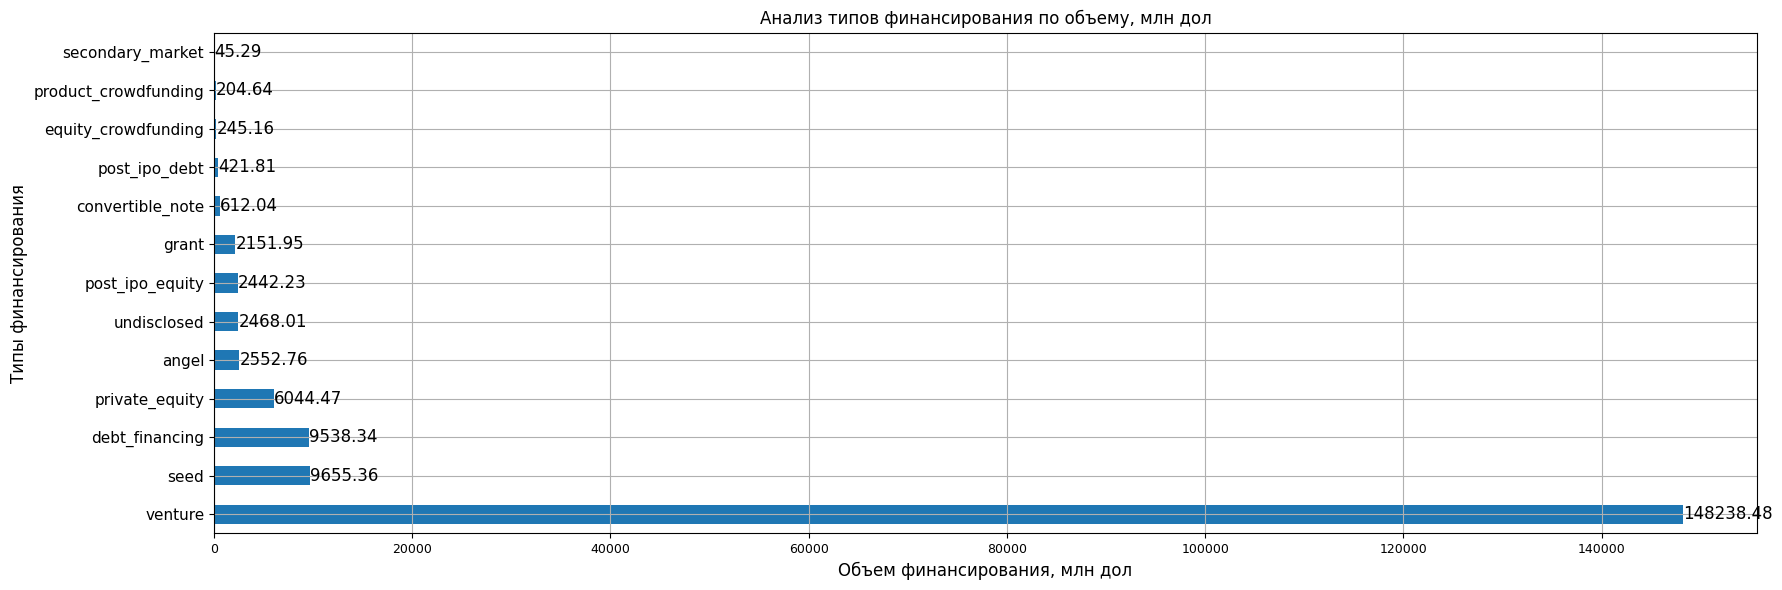

In [44]:
# Построим диаграмму для анализа типов финансирования по объему

diagr = type_finance['sum_finance'].plot(
        kind='barh', 
        figsize=(18,6))
plt.title('Анализ типов финансирования по объему, млн дол')
plt.xlabel('Объем финансирования, млн дол', fontsize=12)
plt.ylabel('Типы финансирования', fontsize=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=11)
extra_for_diagr(kind='barh')

<div style="background-color: #f9f0ff">
    
Максимальный объем финансирования приходится на `venture`. Такие вложения наиболее прибыльные, инвестор получает долю в новом и подающем большие надежды бизнесе. Но одновременно это и самый рисковый тип. `secondary market` -  наименее привлекательный тип финансирования: инвестор приобретает акции не напрямую у эмитента, на вторичном рынке доступ к информации ограничен, цена формируется за счет спроса и предложения и, зачастую, бывает неоправданно завышена или занижена.

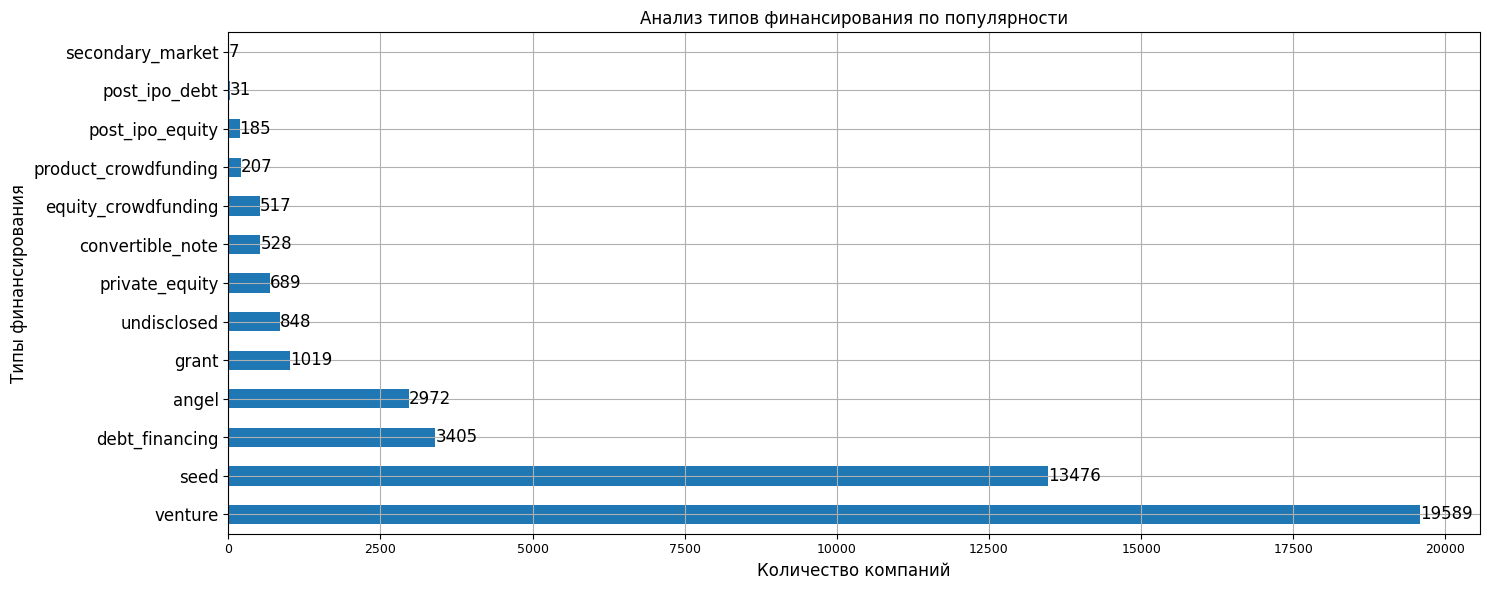

In [45]:
# Построим диаграмму для анализа типов финансирования по популярности

diagr = type_finance['count_of_companies'].sort_values(ascending=False).plot(
        kind='barh', 
        figsize=(15,6))
plt.title('Анализ типов финансирования по популярности')
plt.xlabel('Количество компаний', fontsize=12)
plt.ylabel('Типы финансирования', fontsize=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=12)
extra_for_diagr(kind='barh')

<div style="background-color: #f9f0ff">
    
Здесь наблюдаем практически ту же ситуацию: наиболее популярные венчурные инвестиции, наименее - вторичный рынок.
Из всех типов можно выделить `private_equity`, который при небольшом количестве компаний имеет внушительный объем финансирвания. Действительно, компаний, проверенных временем, не так много, а чтобы получать внушительную долю в бизнесе, нужны большие вложения.
Также интересна позиция `seed`: хотя данный тип финансирования на обеих диаграммах стоит на втором месте, его ситуация обратна `private_equity`: при большом количестве компаний, объем финансирования заметно ниже, если сравнить с показателями `venture`. `seed` еще более рисковые инвестиции, чем `venture`, так как инвестирование происходит на самом раннем этапе зарождения предприятия, и нет  абсолютно никакой статистики по результатам работы нового бизнеса. 

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

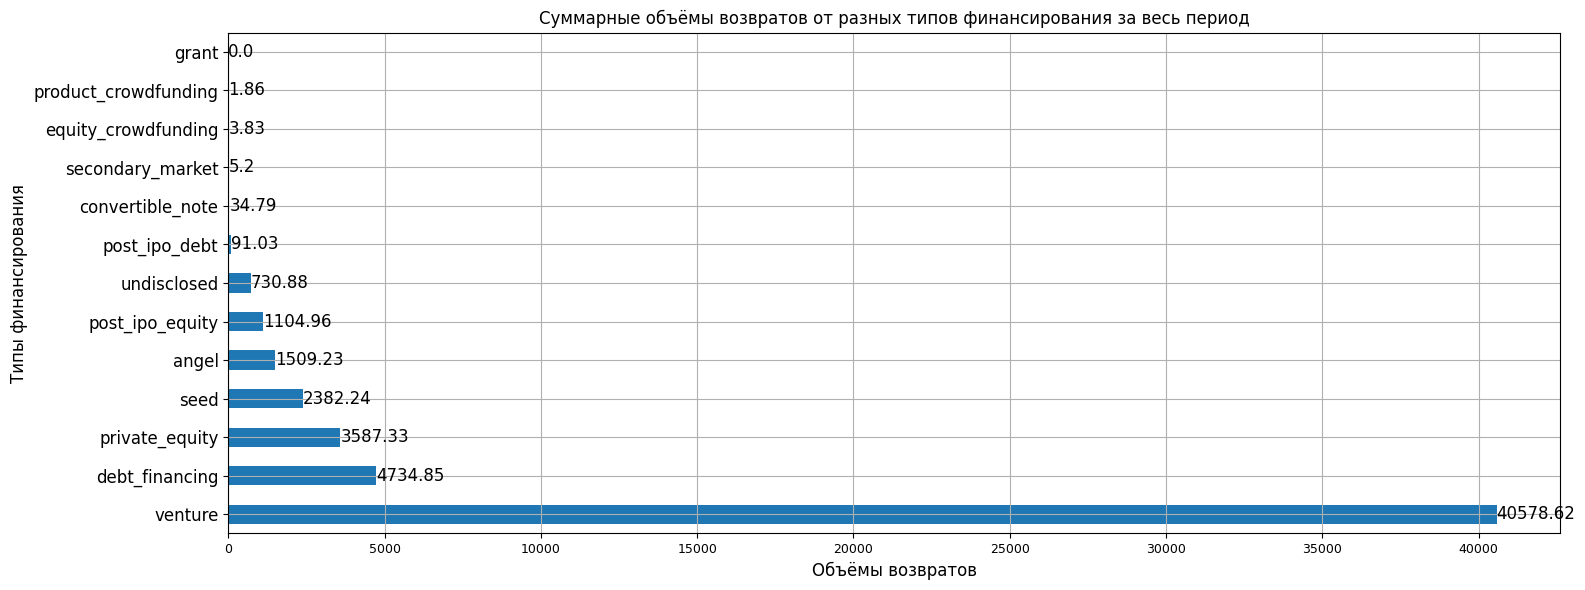

In [46]:
sum_returns = returns[finance_types].sum().sort_values(ascending=False).to_frame(name='sum_return')
sum_returns.index.name = 'finance_type'
sum_returns = sum_returns.round(2)

diagr = sum_returns.plot(
        kind='barh', 
        figsize=(16,6),
        legend=False)
plt.title('Суммарные объёмы возвратов от разных типов финансирования за весь период')
plt.xlabel('Объёмы возвратов', fontsize=12)
plt.ylabel('Типы финансирования', fontsize=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=12)
extra_for_diagr(kind='barh')

<div style="background-color: #f9f0ff">На графике выше видим, что максимальный объем возвратов приходится на те же типы финансирования. Венчурные инвестиции имеют показатель с большим отрывом. Но эти данные не отражают ситуацию в полной мере. Сравним с поступившими объемами финансирования

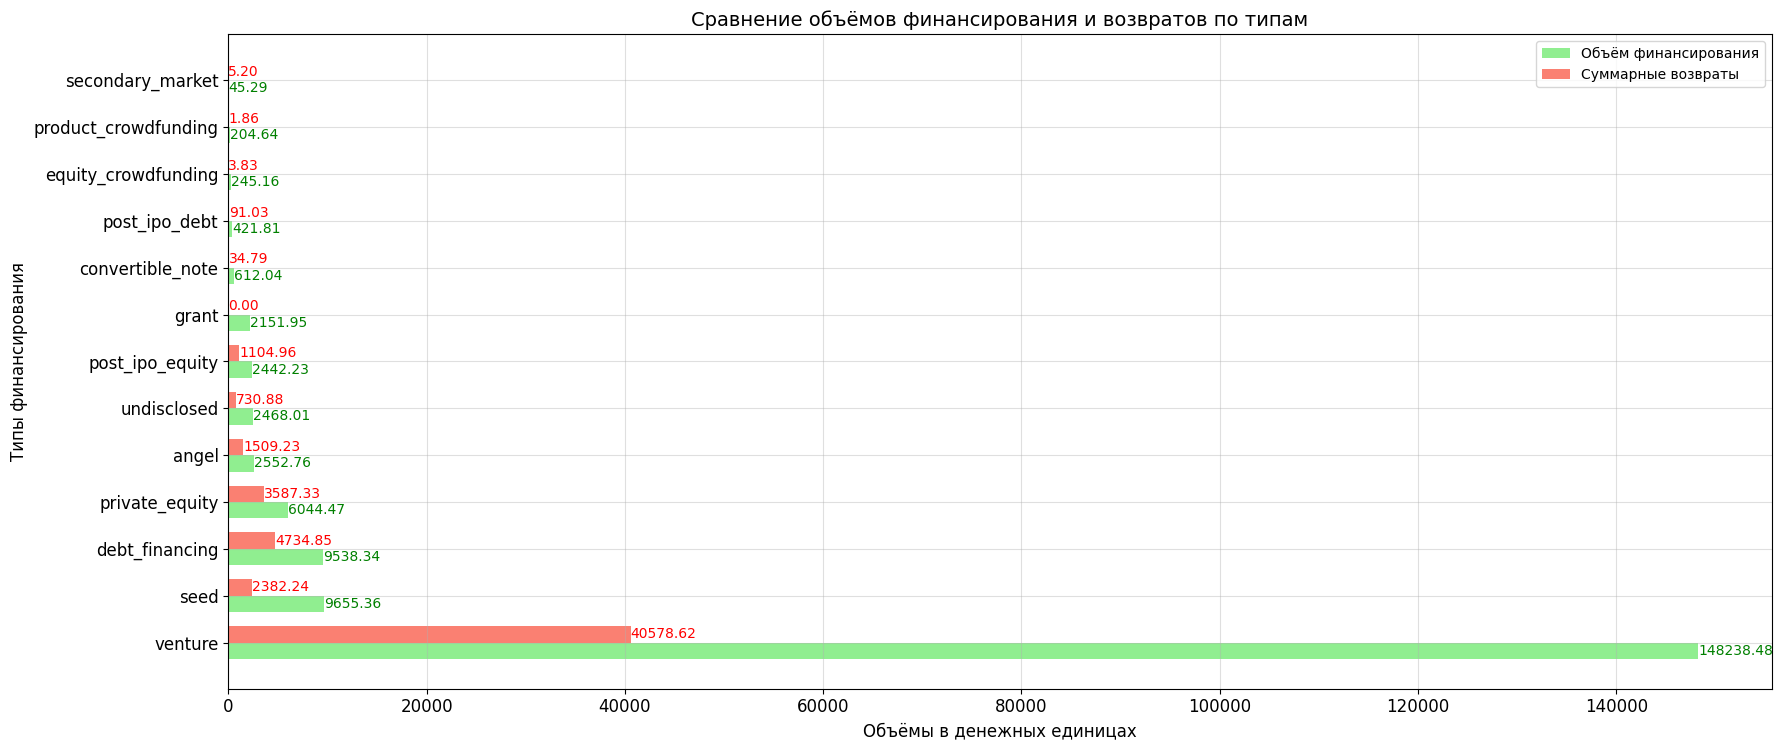

In [47]:
# Здесь сравним объемы финансирования и возвраты в абсолютном выражении

finance = type_finance.merge(sum_returns, on='finance_type')


n = len(finance)
bar_width = 0.35  # ширина каждого бара
index = np.arange(n)

# Создаем диаграмму
fig, ax = plt.subplots(figsize=(18, 8))

# Строим первый набор данных (финансирование)
bars1 = ax.barh(
    index - bar_width/2,  # смещаем влево
    finance['sum_finance'],
    height=bar_width,
    color='lightgreen',
    label='Объём финансирования'
)

# Строим второй набор данных (возвраты)
bars2 = ax.barh(
    index + bar_width/2,  # смещаем вправо
    finance['sum_return'],
    height=bar_width,
    color='salmon',
    label='Суммарные возвраты'
)

# Добавляем подписи к барам
for bars, color in zip([bars1, bars2], ['green', 'red']):
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,  
            bar.get_y() + bar.get_height()/2,  
            f'{width:.2f}',
            ha='left', 
            va='center',
            fontsize=10,
            color=color,
            bbox=dict(facecolor='black', alpha=0.2, pad=1) if color=='white' else None
        )

# Настраиваем оси
plt.yticks(index, finance.index, fontsize=12)  # предполагаем, что index содержит названия типов
plt.xlabel('Объёмы в денежных единицах', fontsize=12)
plt.title('Сравнение объёмов финансирования и возвратов по типам', fontsize=14)

# Добавляем сетку и легенду
plt.grid(alpha=0.4)
plt.legend(loc='upper right', fontsize=10)

# Форматируем подписи
plt.xticks(fontsize=12)
plt.ylabel('Типы финансирования', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<div style="background-color: #f9f0ff">На графике видно, что, несмотря на внушительные суммы, отдача от инвестиций значительно ниже. Не хватает процентного соотношения.

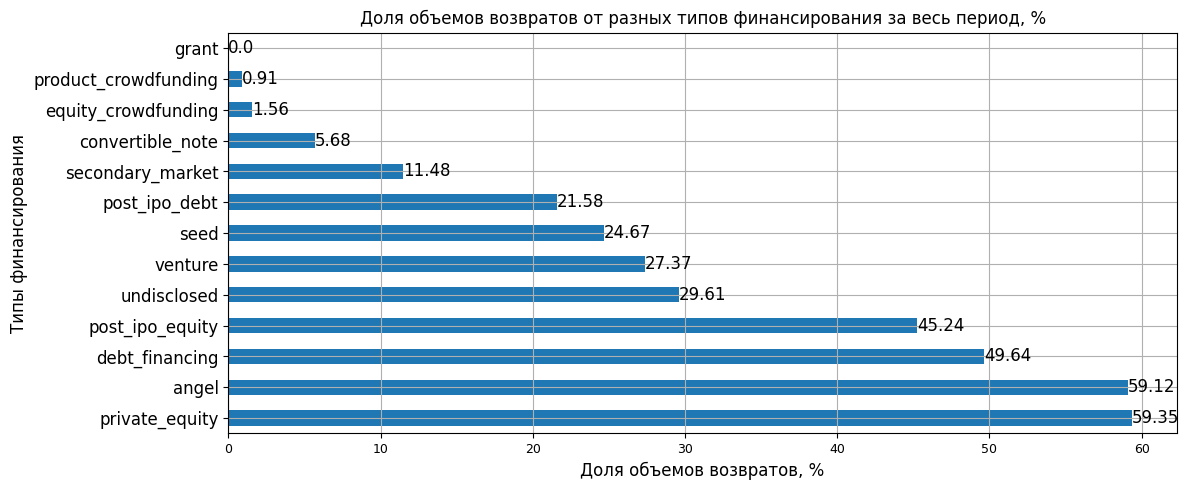

In [48]:
# Здесь сравним объемы финансирования и возвраты в относительном выражении

finance['difference_share'] = (finance['sum_return']/finance['sum_finance']*100).round(2)

diagr = finance['difference_share'].sort_values(ascending=False).plot(
        kind='barh', 
        figsize=(12,5),
        legend=False)
plt.title('Доля объемов возвратов от разных типов финансирования за весь период, %')
plt.xlabel('Доля объемов возвратов, %', fontsize=12)
plt.ylabel('Типы финансирования', fontsize=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=12)
extra_for_diagr(kind='barh')

<div style="background-color: #f9f0ff">
    
Если сравнивать процент отдачи, то самым выгодным вариантом станет `private_equity`, затем `angel` и `debt_financing`. Тип финансирования `debt_financing` имеет хорошие позиции во всех исследованиях. Для компаний это более выгодный способ привлечения капитала, так как инвестору не передается доля в компании, несмотря на то, что зачастую проценты по долговым обязательствам бывают высоки. `private_equity` - более выгодная стратегия для инвестора, так как он будет обладать частью компании и в долгосрочной перспективе получит больше прибыли.

<div style="background-color: #f9f0ff">

**ПРОМЕЖУТОЧНЫЙ ИТОГ**

Исходя из проведенного анализа, можно сделать следующий небольшой итог.
Размер общего финансирования для одной компании имеет большой разброс в значениях. На него влияют разные факторы, как, например, сегмент рынка и тип финнсирования. Типичная сумма для инвестиций - 1 млн дол. Самыми популярными сегментами являются `real estate`, `entertainment`, `consulting`.
Самые распространенные типы финансирования - `venture`, `seed`, `debt_financing`. Тем не менее, `private_equity` имеет самую большую долю возвратов, что говорит о наименьших рисках.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

In [49]:
financing = df[['name', 'funding_total_usd', 'funding_rounds','mid_funding_at_year', 'market']] # Скопируем необходимые данные
financing['value_per_round']=financing['funding_total_usd']/financing['funding_rounds'] # Рассчитаем средний объем одного раунда финансирования
financing

C:\Users\АВС\AppData\Local\Temp\ipykernel_7612\457648602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financing['value_per_round']=financing['funding_total_usd']/financing['funding_rounds'] # Рассчитаем средний объем одного раунда финансирования


,name,funding_total_usd,funding_rounds,mid_funding_at_year,market,value_per_round
1,University of New Brunswick,2.0000,1,2014,niche,2.000000
2,DuPont,9.0000,1,2009,mid,9.000000
3,University of Michigan,7.7000,3,2013,education,2.566667
4,Case Western Reserve University,0.5400,1,2014,education,0.540000
6,Tulane University,12.0000,4,2013,education,3.000000
...,...,...,...,...,...,...
49430,Grid4C,1.5000,1,2014,niche,1.500000
49432,Moko,8.1000,1,2014,niche,8.100000
49433,RiverSilica,1.5000,1,2014,niche,1.500000
49435,DigiByte,0.2500,1,2014,niche,0.250000


In [50]:
# Вычисляем моду, чтобы определить типичный размер средств в рамках одного раунда финансирования
value_mode = pd.pivot_table(financing, values='value_per_round', index='mid_funding_at_year', aggfunc={'value_per_round': lambda x: x.mode().iloc[0]})

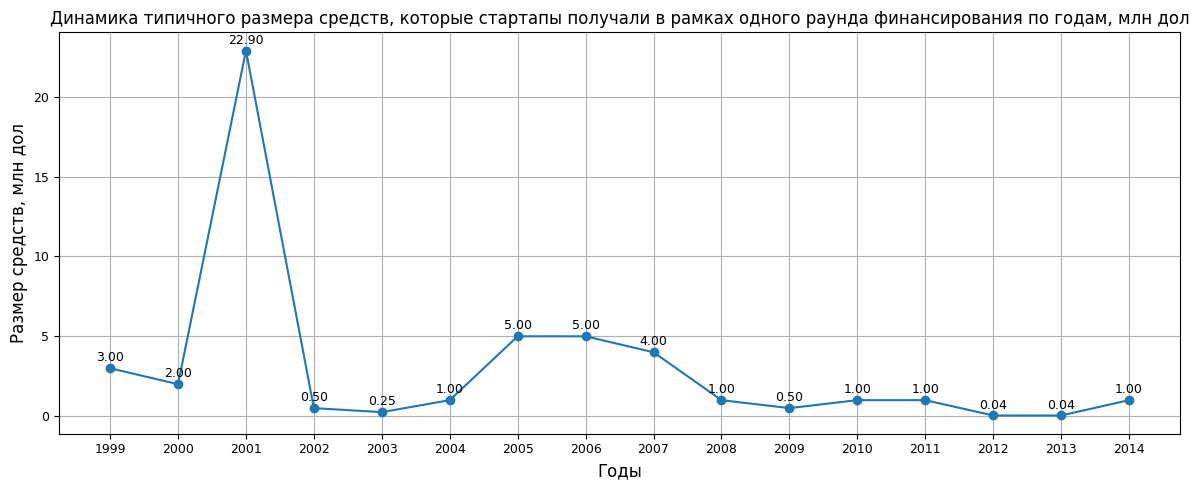

In [51]:
# Строим диаграмму

diagr = value_mode.plot(
    kind = 'line',
    figsize=(12,5),
    legend=False,
    marker='o' 
)
plt.title('Динамика типичного размера средств, которые стартапы получали в рамках одного раунда финансирования по годам, млн дол')
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Размер средств, млн дол', fontsize=12)
plt.grid(0.4)
plt.xticks(ticks=value_mode.index, fontsize=9)
plt.yticks(fontsize=9)

for x, y in zip(value_mode.index, value_mode.values.flatten()):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=9,
        color='black'
    )
plt.tight_layout()
plt.show()

<div style="background-color: #f9f0ff">Исходя из графика можно сказать, что наиболее типичный размер одного раунда финансирования варьирует от 0.5 до 1 млн дол.
Максимальный объем был зафиксирован в 2007 году. Затем был резкий спад, до 2014 года больших изменений не было.

In [52]:
# Рассчитываем количество раундов в каждом году и строим график
count_rounds_per_year = financing.groupby('mid_funding_at_year')['funding_rounds'].sum()

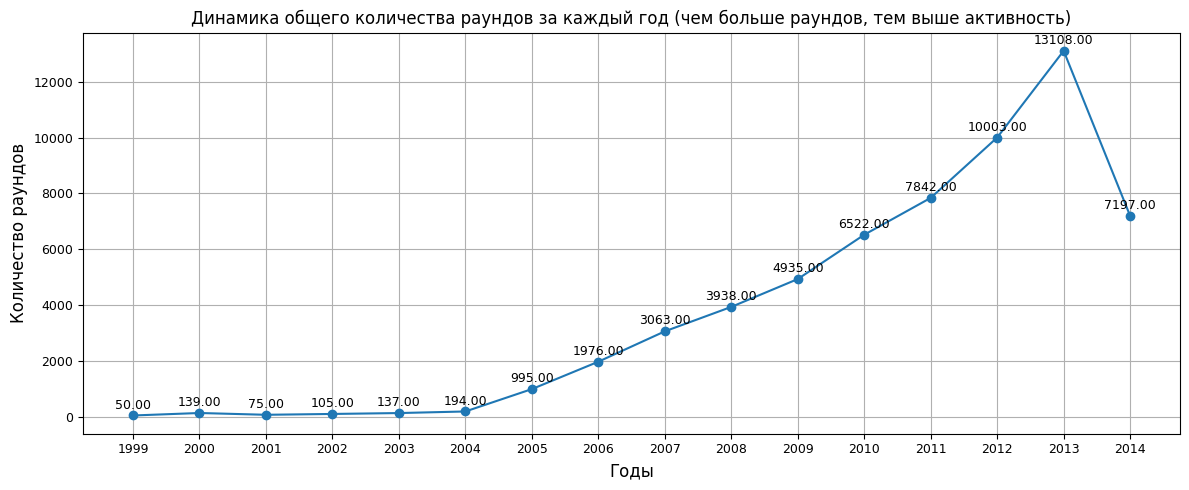

In [53]:
diagr = count_rounds_per_year.plot(
    kind = 'line',
    figsize=(12,5),
    legend=False,
    marker='o' 
)
plt.title('Динамика общего количества раундов за каждый год (чем больше раундов, тем выше активность)')
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Количество раундов', fontsize=12)
plt.grid(0.4)
plt.xticks(ticks=count_rounds_per_year.index, fontsize=9)
plt.yticks(fontsize=9)

for x, y in zip(count_rounds_per_year.index, count_rounds_per_year.values.flatten()):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=9,
        color='black'
    )
plt.tight_layout()
plt.show()

<div style="background-color: #f9f0ff">Наиболее активный год по количеству раундов был 2013. Если сравнить с размером средств в рамках одного раунда финансирования, то видим, что в 2013 году были не такие уж большие суммы. То есть инвестировать можно небольшими суммами.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые было достаточно данных.

In [54]:
market_years = (df.groupby(['market', 'mid_funding_at_year'])['funding_total_usd'].sum().unstack(fill_value=0)) # создаем таблицу
market_years = market_years[market_years[2014] > market_years[2013]] # Отбираем нужные сегменты
market_years = market_years.drop(['mid', 'niche']) # исключаем средние и нишевые
market_years = market_years.T

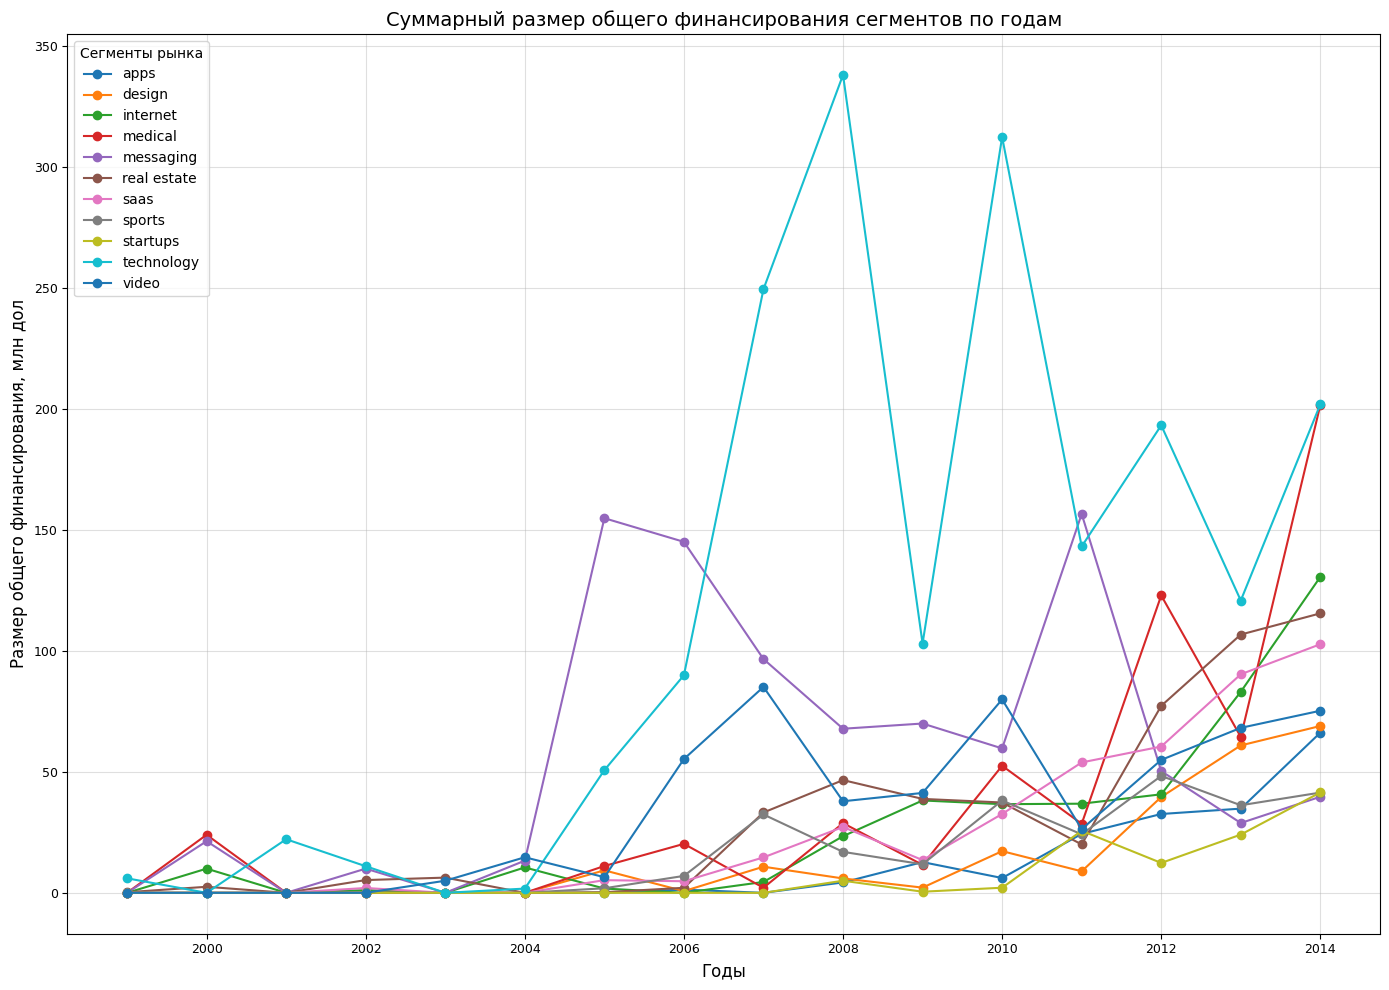

In [55]:
diagr = market_years.plot(
    kind='line',
    figsize=(14, 10),
    marker='o',
    grid=True
)

plt.title('Суммарный размер общего финансирования сегментов по годам', fontsize=14)
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Размер общего финансирования, млн дол', fontsize=12)
plt.grid(visible=True, alpha=0.4)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.legend(
    title='Сегменты рынка',
    loc='upper left',
    fontsize=10
)
plt.tight_layout()
plt.show()


<div style="background-color: #f9f0ff">
    
Самый активный рост наблюдается в сегменте `manufacturing`. Пиком развития был 2011 год. Несмотря на небольшой спад, сегмент занимает лидирующие позиции. За ним следует `technology`. Уверенный рост можно наблюдать в сегменте `medical`. Линия не имеет резких колебаний, постепенно и уверенно идет вверх.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. Слишком большие аномальные значения заменим на пропуски.

In [56]:
finance_years = df.groupby('mid_funding_at_year')[finance_types].sum().round(2)
returns_years = returns.groupby('year')[finance_types].sum()
returns_share = (returns_years / finance_years * 100).round(2)
mask1 = finance_years == 0 # не стала добавлять числа, а заменила на нули
returns_share[mask1] = 0
# Заменим значения, превышающие 100, на пропуски
for col in finance_types:
    mask = (returns_share[col] > 100)
    returns_share.loc[mask, col] = np.nan
returns_share

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
1999,NaN,NaN,0.00,NaN,0.00,NaN,NaN,0.0,NaN,0.00,0.00,0.00,0.00
2000,99.64,13.77,0.00,39.82,0.00,61.86,24.65,0.0,0.00,27.09,0.00,2.59,0.00
2001,70.24,6.81,0.00,47.00,0.67,77.02,NaN,0.0,0.00,0.00,0.00,0.00,0.00
2002,62.94,60.40,0.00,60.89,0.00,22.34,NaN,0.0,20.13,NaN,0.00,0.00,0.00
2003,50.52,53.17,0.00,91.44,0.00,35.74,60.57,0.0,7.76,0.00,0.00,0.00,0.00
2004,54.86,64.87,0.00,52.76,0.00,43.96,83.38,0.0,0.00,0.00,0.00,0.00,0.00
2005,67.46,49.57,0.00,35.67,0.00,33.04,49.77,0.0,48.00,73.12,0.00,0.00,0.00
2006,91.27,30.10,20.43,74.30,16.64,56.78,66.54,0.0,13.72,54.14,0.00,0.00,0.00
2007,32.51,25.66,0.00,34.91,22.80,39.83,75.58,0.0,57.91,NaN,0.00,0.00,0.00
2008,28.52,16.21,0.00,31.10,5.95,78.97,41.16,0.0,61.28,NaN,0.00,0.00,0.00


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

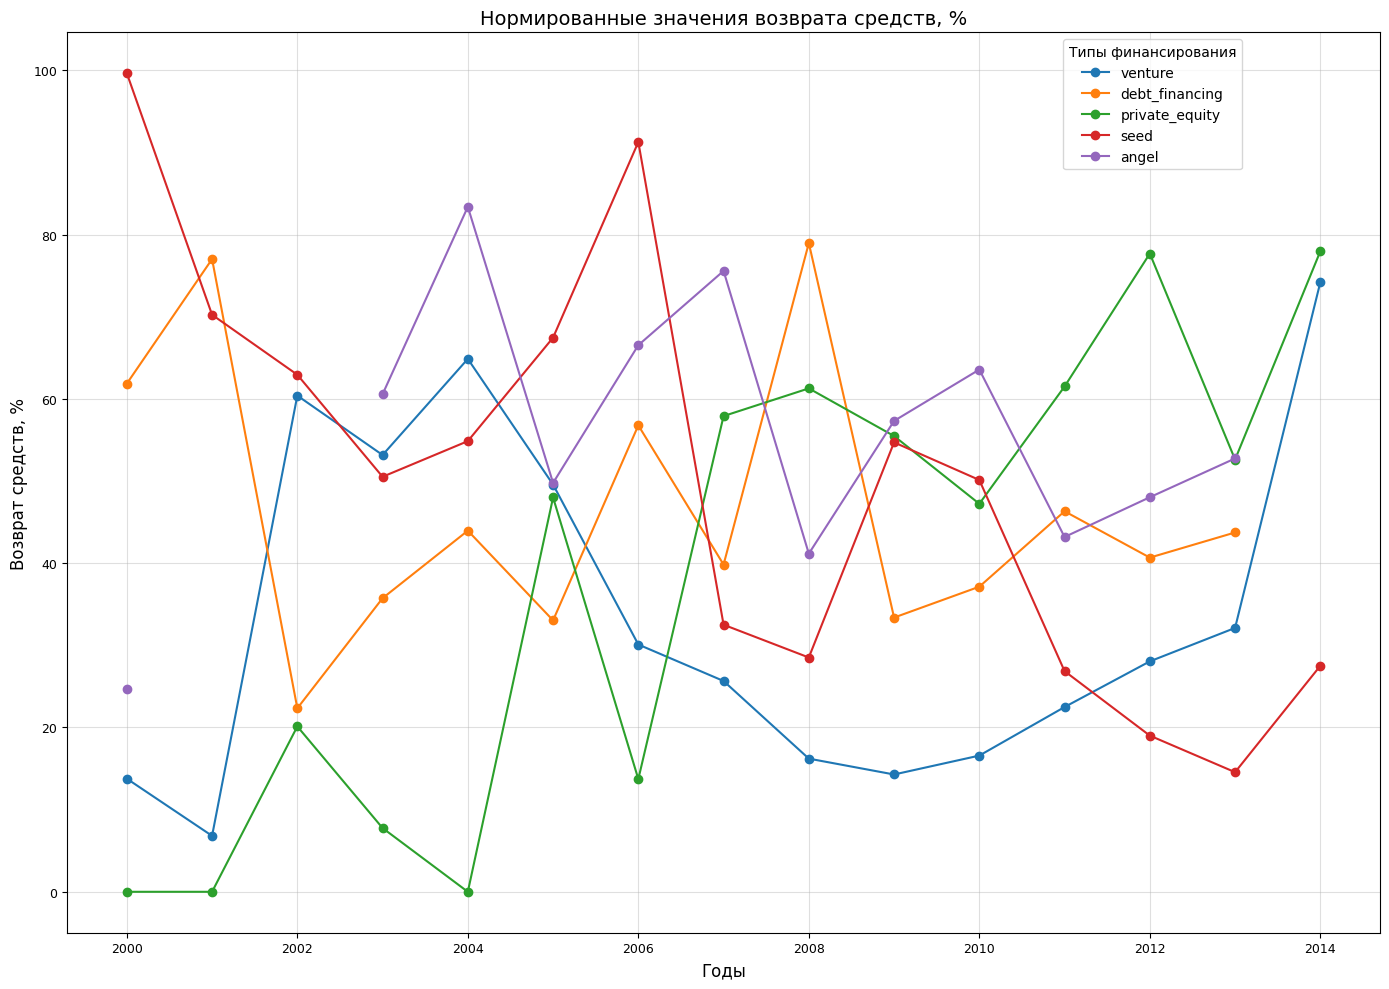

In [57]:
columns = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
diagr = returns_share.plot(
    kind='line',
    y=columns,
    figsize=(14, 10),  
    marker='o',       
    grid=True
)

plt.title('Нормированные значения возврата средств, %', fontsize=14)
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Возврат средств, %', fontsize=12)
plt.grid(visible=True, alpha=0.4)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.legend(
    title='Типы финансирования',
    loc='upper right',
    bbox_to_anchor=(0.9, 1),
    fontsize=10
)
plt.tight_layout()
plt.show()

<div style="background-color: #f9f0ff">
    
Судя по графику, нельзя однозначно сказать, что какой-то тип финансирования будет гарантировать стабильный и плавный приток прибыли от инвестиций.
Было бы лучше даже ориентироваться на показатели после 2006 года, где колебаниий намного меньше и разброс невелик. В этом случае `private_equity` выглядит наиболее привлекательным: высоки показатели и небольшие колебания. Также `angel` имеет хороший график - менее прибыльный тип, но и без резких скачков. Но такой тип финансирования подойдет не всем: бизнес-ангелы рискуют своим собственным капиталом на стадии pre-seed, то есть когда существует только идея, поэтому таким инвесторам необходимо иметь большой опыт в инвестировании и видении рынка. Хуже всех "чувствует себя" `seed`. В целом `seed` и `angel` можно было бы объединить, так как они практически не отличаются друг от друга. Единственное, `seed` предполагает воложения большего капитала, чем `angel`. Отсюда могут возникнуть большие потери из-за больших сумм. 

<div style="background-color: #f9f0ff">
    
**ПРОМЕЖУТОЧНЫЙ ИТОГ**

 - Для эффективного финансирования объем инвестиционного капитала не имеет большого значения, так как можно инвестировать и с небольшими средствами - от 0.5 млн дол. Такие суммы наиболее распространены в рамках одного раунда финансирования.<br>
 - Активно развивающиеся сегменты и наращивающие обороты - это `manufacturing`,  `technology`,  `medical`. В целом, их взлет можно объяснить: человечество вступило в эпоху потребления, товары становятся разнообразными и доступными, выходят из строя быстро и требуют замены. А производители активно ищут способы закрытия потребностей покупателя. Технологии также не дремлют: автоматизация процессов, роботизация, замена рутинной работы машинами позволяют минимизировать издержки, облегчают как стадии производства, так и обычные повседневные дела. Автоматизация придет в каждый дом - от умного дома до робота-пылесоса. Такие технологии приводят к меньшей подвижности, человек отвыкает от физичекой нагрузки и обрекает свой организм на приобретение хронических заболеваний. И тут на помощь придет конечно же медицина - одна из процветающих сегментов рынка.<br>
 - Если инвестор обладает собственным капиталом и уверен в своем опыте, то выгодно стать бизнес-ангелом. Но этот путь рискованный. Более надежный вариант - это `private_equity`, так как финансирование направлено на развитие уже устоявшихся компаний, имеющих историю своих взлетов и падений.


##  Итоговый вывод и рекомендации

<div style="background-color: #f9f0ff">В ходе исследования проанализировано 54294 компании в рамках финансирования стартапов. Данные включали общую информацию о компаниях, их расположение, дату основания компании, дату финансирования, отрасль компании, объем привлеченных инвестиций, типы финансирования, разбивку по раундам финансирования с указанием сумм, суммы возвратов по типам финансирования.
Проведен анализ данных, с помощью которого составлены рекомендации для инвестора: какой выбрать сегмент рынка и тип финансирования в 2015 году. Были рассмотрены такие вопросы: наиболее популярные типы финансирования по количеству компаний и объему средств, активность инвестиций на рынке, динамика изменения размера финансирования, а также  доля возвращенных средств.<br>
В данных множество пропусков, самые существенные - это отсутствие общего объёма привлечённых инвестиций. Вместе с дубликатами составляют около 25% общего объема данных. Также в результате предобработки остались пропуски в данных по сегментам рынка, но их доля несущественна - около 6%. Остальные пропуски не влияют на исследования, так как не используются в анализе.


<div style="background-color: #f9f0ff">
    
*В результате анализа можно сформулировать следующие выводы:*

 - в процессе анализа компании были разделены в три группы по срокам финансирования. Самой распространенной стратегией стало "однораундовое" финансирование для большинства компаний. Но по объему инвестиций большую долю имеет срок финансирования более года. Значит, если необходимо привлечь внушительный капитал, то нужно больше этапов и долгосрочный период - привлекаются больше инвесторов на каждом из раундов. Также в плане организации проведения удобней разбивать финансирование на раунды, чем готовиться к одному большому раунду, подготовка к которому может занять длительное время.<br>
Далее компании были разделены на сегменты: наибольшее количество компаний приходится на `software`, `biotechnology` и `mobile`. По предварительной оценке данные отрасли имеют наибольшее развитие и востребованность.<br>
 - в относительном выражении компании, получившие аномальное финансирование, принадлежат сегментам `real estate`, `entertainment`, `consulting`.
В целом, это ожидаемо, так как сегмент недвижимости в большинстве случаев требует значительных капиталовложений для реализации проектов. Если рассматривать типичный размер инвестиций в денежном выражении, то он будет равен 1 млн дол.
 - максимальный объем финансирования приходится на `venture` - один из самых рискованных типов финансирования, но и самый прибыльный: используя эту стратегию, инвестор будет обладать большой долей в компании, и при успешном старте, прибыль будет соразмерна этой доле. Другой вариант инвестирования - `private_equity`, менее рискованный, чем предыдущий тип, и требующий долгосрочных вложений, но более надежный, так как средства вкладываются уже в устоявшиеся компании.
 - к сожалению, невозможно предугадать, какой из видов финансирования будет наиболее выгоден, так как рынок не стабилен, возможны как резкие взлеты, так и падения. Если рассматривать период до 2014 года, то более-менее себя хорошо чувствуют `private_equity` и `angel`.
 - с сегментами рынка дела обстоят проще: в выборе сферы деятельности важную роль играют потребности покупателя. Для периода до 2014 года - это `manufacturing`, `technology`, `medical`.

<div style="background-color: #f9f0ff">
    
*Рекомендации:*

**Выбор типа финансирования**<br>
Если инвестор рассчитывает вкладывать средства на **краткосрочный период**:
- при наличии небольшого капитала можно выбрать тип финансирования `angel`. Крупными средствами лучше не рисковать, потому что данный тип финансирования предполагает вложения в компанию на стадии создания бизнес-плана.<br>
Плюсы: инвестор будет иметь долю в компании, большая прибыль, краткосрочный период - 3-5 лет<br>
Минусы: высокие риски<br>
- при наличии больших сумм можно выбрать `venture` - менее рисковано, чем `angel`, но как показали исследования, процент возврата средств мал.<br>
В обоих случаях нужен большой опыт в инвестировании, чутье, дальновидность, оценка всех рисков, которые возникнут на этапе создания новой компании.

Если инвестор рассчитывает вкладывать средства на **долгосрочный период**: лучше иметь большой капитал, так как прибыль не высока.<br>
Можно выбрать тип `private_equity` или `debt_financing`. Преимущества в том, что это менее рискованные стратегии. Если инвестору важно купить долю в компании, то подойдет `private_equity`, если это не имеет значения, то `debt_financing`. Оба хорошо себя показали в анализе доли возврата средств. 
Но `debt_financing` - это все-таки долговое обязательство и фактически инвестор выступает в виде кредитора и получает проценты, то с экономической и этической точки зрения - это не самый лучший выбор. <br>
Как показали исследования, количество компаний с типом финансирования `private_equity` намного меньше, то есть возможна конкуренция. <br>
Плюсы: надежность<br>
Минусы: долгосрочный период, прибыль не такая большая.<br>
Таким образом, чем меньше период финансирования, тем больше прибыль, но и выше риски.

<div style="background-color: #f9f0ff">
    
**Выбор сегмента рынка**<br>
К сожалению, в данных отсутствует информация о возвратах средств по отраслям. Поэтому рекомендации по этому вопросу будут поверхностными.<br>
Наиболее традиционный и проверенный временем сегмент - это `real estate`, наиболее надежный вариант, наименее рискованный, но и прибыли тоже меньше, предполагает долгосрочные вложения.<br>
Тенденцию к росту имет сегмент `manufacturing`, `medical`. Скорее всего это связано с ростом спроса на потребительские товары и забота о здоровье. Здесь больше подойдет краткосрочное финансирование, так как товар быстро теряет свою ценность и уникальность.<br>
Исходя из того, что наибольшее количество компаний приходится на `software`, `biotechnology`, спрос на товары и услуги компаний этих сегментов высок. Поэтому нужно идти в этом направлении - создание уникального ПО, генная инженерия и фармацевтика.<br>
Рекомендуется провести дополнительное исследование потребительского спроса

<div style="background-color: #f9f0ff">
    
Несколько слов о **сумме инвестиционного капитала**: если падает выбор на краткосрочное финансирование - лучше ограничиться небольшой суммой; если долгосрочный период - нужны большие вложения. Кратко:<br>
*`маленький срок - маленькие вложения - большая прибыль - большие риски`*<br>
*`большой срок - крупные вложения - маленькая прибыль - маленькие риски`*<br>

<div style="background-color: #f9f0ff">
    
В заключении хотелось добавить, что данное исследование имеет множество оговорок и условий. В данном анализе участвовали компании стран с развитой экономикой, где искушенного потребителя сложно чем-то удивить и привлечь его внимание, также он формирует платежеспособный спрос. Его уровень жизни высок, образ жизни разнообразен. Поэтому было бы интересно также составить портрет того самого потребителя, который будет пользоваться услугой или товаром компании, в которую хотят инвестировать. Также не стоит забывать о политической ситуации, налоговых, экономических реформах. Ну, и диверсифицировать свой капитал.